# mIF Image segmentation

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


3206719300.py (18): Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.


Text(0.5, 1.0, 'prediction + input overlay')

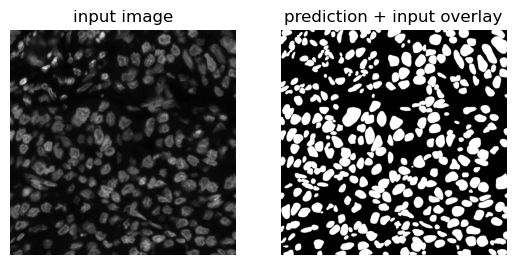

In [2]:
from stardist.models import StarDist2D

from stardist.data import test_image_nuclei_2d
from stardist.plot import render_label
from csbdeep.utils import normalize
import matplotlib.pyplot as plt
import imageio
import numpy as np

# prints a list of available models
StarDist2D.from_pretrained()

# creates a pretrained model
model = StarDist2D.from_pretrained('2D_versatile_fluo')


path = '/data4/ceiling/workspace/HCC/filtered_patches/DAPI/201413211.4_Scan1/025572_043184.png'
img = imageio.imread(path)
labels, _ = model.predict_instances(normalize(img))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("input image")

plt.subplot(1,2,2)
# plt.imshow(render_label(labels, img=img))
plt.imshow(np.uint8(255 * (labels > 0)), cmap='gray')
plt.axis("off")
plt.title("prediction + input overlay")

# Filter data based on Cell Mask

In [ ]:
import os
import imageio
import shutil
import numpy as np

slide_name = '201524599.4_Scan1'

channels = ['DAPI', 'CD3', 'CD4', 'CD8', 'HE', 'CD19', 'CD68', 'Foxp3', 'SampleAF', 'Nuclei']
mask_root = '/data/ceiling/workspace/HCC/hover_net/output_tiles_Pannuke/'
org_root = '/data/ceiling/workspace/HCC/patches/'
save_root = '/data/ceiling/workspace/HCC/filtered_patches/'

DAPI_root = org_root + 'DAPI'
mask_path = os.path.join(mask_root, slide_name)
DAPI_path = os.path.join(DAPI_root, slide_name)
channels_path = [os.path.join(save_root, c, slide_name) for c in channels]
for c in channels_path:
    os.makedirs(c, exist_ok=True)

sum_threshold = 50
max_threshold = 50
for part_name in os.listdir(mask_path):
    if part_name[0] == '.':
        continue
    else:
        mask_part = os.path.join(mask_path, part_name, 'mask')
    for patch_name in os.listdir(mask_part):
        if patch_name[0] == '.':
            continue
        mask = imageio.imread(os.path.join(mask_part, patch_name))
        dapi = imageio.imread(os.path.join(DAPI_path, patch_name))
        if np.sum(mask / 255) < sum_threshold or np.max(dapi) < max_threshold:
            print(patch_name)
            continue
        else:
            continue
            # for step, c in enumerate(channels_path):
            #     if 'Nulcei' in c:
            #         shutil.copy(os.path.join(mask_part, patch_name), os.path.join(c, patch_name))
            #     else:
            #         shutil.copy(os.path.join(os.path.join(org_root, channels[step], slide_name, patch_name)), os.path.join(c, patch_name))